In [23]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error

import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader

In [24]:
df = pd.read_csv("../data/processed/dk2_merged_price_weather_energy.csv")

df["HourUTC"] = pd.to_datetime(df["HourUTC"])
df["HourDK"] = pd.to_datetime(df["HourDK"])

df = df.sort_values("HourUTC").reset_index(drop=True)

print("Rows:", len(df))
print("Date range:", df["HourUTC"].min(), "→", df["HourUTC"].max())
print("Missing values:", df.isna().sum().sum())

df.head()

Rows: 9824
Date range: 2024-08-17 06:00:00 → 2025-09-30 13:00:00
Missing values: 0


,HourUTC,HourDK,PriceArea,SpotPriceEUR,hour,day_of_week,month,year,is_weekend,price_lag_24h,...,offshore_wind_mwh,onshore_wind_mwh,solar_mwh,total_wind_mwh,renewable_generation_mwh,net_load_mwh,ExchangeSE_MWh,ExchangeGE_MWh,ExchangeGreatBelt_MWh,PowerToHeatMWh
0,2024-08-17 06:00:00,2024-08-17 08:00:00,DK2,103.430000,8,5,8,2024,1,124.830002,...,139.575607,12.631012,290.954754,152.206619,443.161373,913.084285,1004.938750,-542.164000,181.2,32.783193
1,2024-08-17 07:00:00,2024-08-17 09:00:00,DK2,84.000000,9,5,8,2024,1,100.949997,...,111.449682,14.223518,464.444211,125.673200,590.117411,897.563125,1164.431492,-839.658984,202.5,24.287895
2,2024-08-17 08:00:00,2024-08-17 10:00:00,DK2,69.489998,10,5,8,2024,1,76.150002,...,86.846481,11.792317,592.522881,98.638798,691.161679,871.185718,1220.923492,-943.107016,244.5,15.592138
3,2024-08-17 09:00:00,2024-08-17 11:00:00,DK2,54.160000,11,5,8,2024,1,59.830002,...,56.012000,14.692761,641.920324,70.704761,712.625085,884.160102,1320.748250,-959.805000,171.9,14.801758
4,2024-08-17 10:00:00,2024-08-17 12:00:00,DK2,46.830002,12,5,8,2024,1,50.680000,...,35.773500,14.832262,675.559553,50.605762,726.165315,868.566350,1008.507250,-865.089992,340.9,12.442353


In [25]:
horizon = 24

df["target_24h_ahead"] = df["SpotPriceEUR"].shift(-horizon)

df = df.dropna(subset=["target_24h_ahead"]).reset_index(drop=True)

print("Rows after target:", len(df))

Rows after target: 9800


In [26]:
target_col = "target_24h_ahead"

exclude_cols = [
    "HourUTC",
    "HourDK",
    "PriceArea",
    "target_next_hour",
    "target_24h_ahead",
]

feature_cols = [col for col in df.columns if col not in exclude_cols]

X_raw = df[feature_cols].select_dtypes(include=["number"])
y_raw = df[target_col]

feature_cols = X_raw.columns.tolist()

print("Number of features:", len(feature_cols))
feature_cols

Number of features: 32


['SpotPriceEUR',
 'hour',
 'day_of_week',
 'month',
 'year',
 'is_weekend',
 'price_lag_24h',
 'price_lag_48h',
 'price_lag_168h',
 'price_rolling_mean_24h',
 'price_rolling_std_24h',
 'price_rolling_mean_168h',
 'price_rolling_std_168h',
 'temperature_2m',
 'wind_speed_10m',
 'wind_speed_100m',
 'cloud_cover',
 'shortwave_radiation',
 'GrossConsumptionMWh',
 'CentralPowerMWh',
 'LocalPowerMWh',
 'CommercialPowerMWh',
 'offshore_wind_mwh',
 'onshore_wind_mwh',
 'solar_mwh',
 'total_wind_mwh',
 'renewable_generation_mwh',
 'net_load_mwh',
 'ExchangeSE_MWh',
 'ExchangeGE_MWh',
 'ExchangeGreatBelt_MWh',
 'PowerToHeatMWh']

In [27]:
size = int(len(df) * 0.7)

X_train = X_raw.iloc[:size].copy()
X_test = X_raw.iloc[size:].copy()

y_train = y_raw.iloc[:size].copy()
y_test = y_raw.iloc[size:].copy()

time_test = df["HourDK"].iloc[size:].copy()

print("Train:", X_train.shape)
print("Test:", X_test.shape)

Train: (6860, 32)
Test: (2940, 32)


In [28]:
feature_scaler = StandardScaler()
target_scaler = StandardScaler()

X_train_scaled = feature_scaler.fit_transform(X_train)
X_test_scaled = feature_scaler.transform(X_test)

y_train_scaled = target_scaler.fit_transform(
    y_train.values.reshape(-1, 1)
).ravel()

y_test_scaled = target_scaler.transform(
    y_test.values.reshape(-1, 1)
).ravel()

In [29]:
def create_sequences(X, y, window_size):
    X_seq = []
    y_seq = []

    for i in range(window_size, len(X)):
        X_seq.append(X[i - window_size:i])
        y_seq.append(y[i])

    return np.array(X_seq), np.array(y_seq)

In [30]:
window_size = 24

X_train_seq, y_train_seq = create_sequences(
    X_train_scaled,
    y_train_scaled,
    window_size
)

X_test_seq, y_test_seq = create_sequences(
    X_test_scaled,
    y_test_scaled,
    window_size
)

print("X_train_seq:", X_train_seq.shape)
print("y_train_seq:", y_train_seq.shape)
print("X_test_seq:", X_test_seq.shape)
print("y_test_seq:", y_test_seq.shape)

X_train_seq: (6836, 24, 32)
y_train_seq: (6836,)
X_test_seq: (2916, 24, 32)
y_test_seq: (2916,)


In [31]:
device = torch.device(
    "mps" if torch.backends.mps.is_available()
    else "cuda" if torch.cuda.is_available()
    else "cpu"
)

print("Using device:", device)

Using device: cuda


In [32]:
X_train_tensor = torch.tensor(X_train_seq, dtype=torch.float32)
y_train_tensor = torch.tensor(y_train_seq, dtype=torch.float32).view(-1, 1)

X_test_tensor = torch.tensor(X_test_seq, dtype=torch.float32)
y_test_tensor = torch.tensor(y_test_seq, dtype=torch.float32).view(-1, 1)

In [33]:
val_size = int(len(X_train_tensor) * 0.2)

X_val_tensor = X_train_tensor[-val_size:]
y_val_tensor = y_train_tensor[-val_size:]

X_train_tensor_final = X_train_tensor[:-val_size]
y_train_tensor_final = y_train_tensor[:-val_size]

train_dataset = TensorDataset(X_train_tensor_final, y_train_tensor_final)
val_dataset = TensorDataset(X_val_tensor, y_val_tensor)

train_loader = DataLoader(
    train_dataset,
    batch_size=64,
    shuffle=False
)

val_loader = DataLoader(
    val_dataset,
    batch_size=64,
    shuffle=False
)

In [34]:
class ImprovedLSTMRegressor(nn.Module):
    def __init__(self, input_size, hidden_size=128, num_layers=2, dropout=0.3):
        super().__init__()

        self.lstm = nn.LSTM(
            input_size=input_size,
            hidden_size=hidden_size,
            num_layers=num_layers,
            dropout=dropout,
            batch_first=True
        )

        self.layer_norm = nn.LayerNorm(hidden_size)

        self.regressor = nn.Sequential(
            nn.Linear(hidden_size, 64),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(64, 32),
            nn.ReLU(),
            nn.Linear(32, 1)
        )

    def forward(self, x):
        lstm_out, _ = self.lstm(x)
        last_hidden_state = lstm_out[:, -1, :]
        x = self.layer_norm(last_hidden_state)
        x = self.regressor(x)
        return x

In [35]:
input_size = X_train_tensor.shape[2]

model = ImprovedLSTMRegressor(
    input_size=input_size,
    hidden_size=128,
    num_layers=2,
    dropout=0.3
).to(device)

criterion = nn.MSELoss()

optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=0.001,
    weight_decay=1e-4
)

scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode="min",
    factor=0.5,
    patience=5
)

In [36]:
epochs = 100
patience = 12

best_val_loss = float("inf")
best_model_state = None
epochs_without_improvement = 0

train_losses = []
val_losses = []

for epoch in range(epochs):
    model.train()
    epoch_train_losses = []

    for X_batch, y_batch in train_loader:
        X_batch = X_batch.to(device)
        y_batch = y_batch.to(device)

        optimizer.zero_grad()

        y_pred = model(X_batch)
        loss = criterion(y_pred, y_batch)

        loss.backward()

        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)

        optimizer.step()

        epoch_train_losses.append(loss.item())

    train_loss = np.mean(epoch_train_losses)
    train_losses.append(train_loss)

    model.eval()
    epoch_val_losses = []

    with torch.no_grad():
        for X_batch, y_batch in val_loader:
            X_batch = X_batch.to(device)
            y_batch = y_batch.to(device)

            y_pred = model(X_batch)
            val_loss = criterion(y_pred, y_batch)

            epoch_val_losses.append(val_loss.item())

    val_loss = np.mean(epoch_val_losses)
    val_losses.append(val_loss)

    scheduler.step(val_loss)

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        best_model_state = model.state_dict()
        epochs_without_improvement = 0
    else:
        epochs_without_improvement += 1

    if (epoch + 1) % 5 == 0:
        print(
            f"Epoch {epoch + 1}/{epochs} "
            f"- Train loss: {train_loss:.4f} "
            f"- Val loss: {val_loss:.4f}"
        )

    if epochs_without_improvement >= patience:
        print(f"Early stopping at epoch {epoch + 1}")
        break

model.load_state_dict(best_model_state)

Epoch 5/100 - Train loss: 0.7190 - Val loss: 0.3398
Epoch 10/100 - Train loss: 0.5037 - Val loss: 0.3539
Epoch 15/100 - Train loss: 0.2842 - Val loss: 0.4014
Early stopping at epoch 16


<All keys matched successfully>

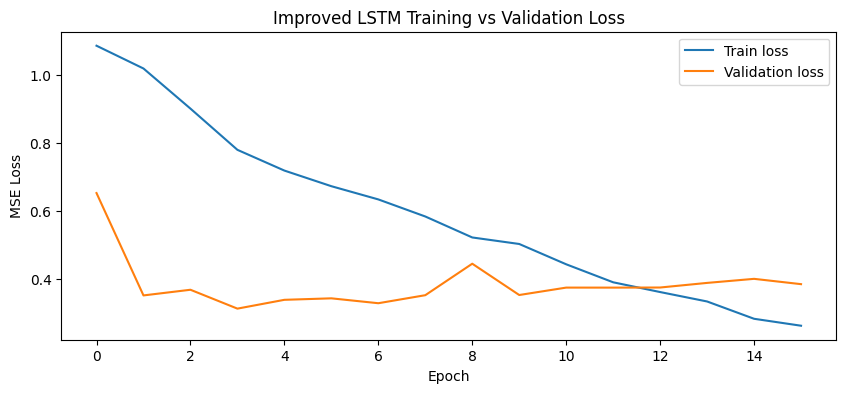

In [37]:
plt.figure(figsize=(10, 4))
plt.plot(train_losses, label="Train loss")
plt.plot(val_losses, label="Validation loss")
plt.title("Improved LSTM Training vs Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("MSE Loss")
plt.legend()
plt.show()

In [38]:
model.eval()

with torch.no_grad():
    X_test_tensor_device = X_test_tensor.to(device)
    y_pred_scaled = model(X_test_tensor_device).cpu().numpy().ravel()

In [39]:
y_pred = target_scaler.inverse_transform(
    y_pred_scaled.reshape(-1, 1)
).ravel()

y_true = target_scaler.inverse_transform(
    y_test_seq.reshape(-1, 1)
).ravel()

In [40]:
mae = mean_absolute_error(y_true, y_pred)
rmse = np.sqrt(mean_squared_error(y_true, y_pred))

lstm_result = {
    "model": "Improved PyTorch LSTM 24h",
    "MAE": round(mae, 2),
    "RMSE": round(rmse, 2),
}

lstm_result

{'model': 'Improved PyTorch LSTM 24h', 'MAE': 34.43, 'RMSE': np.float64(46.71)}

In [41]:
results_24h = pd.read_csv("../reports/model_comparison_24h_DK2.csv")

comparison_lstm = pd.concat(
    [results_24h, pd.DataFrame([lstm_result])],
    ignore_index=True
).sort_values("MAE").reset_index(drop=True)

comparison_lstm

,model,MAE,RMSE
0,XGBoost 24h,25.38,34.53
1,Current price baseline 24h,28.30,42.29
2,Improved PyTorch LSTM 24h,34.43,46.71
3,Rolling mean 168h baseline,37.69,49.88
4,Rolling mean 24h baseline,40.72,53.81


In [42]:
comparison_lstm.to_csv(
    "../reports/model_comparison_24h_with_improved_lstm_DK2.csv",
    index=False
)

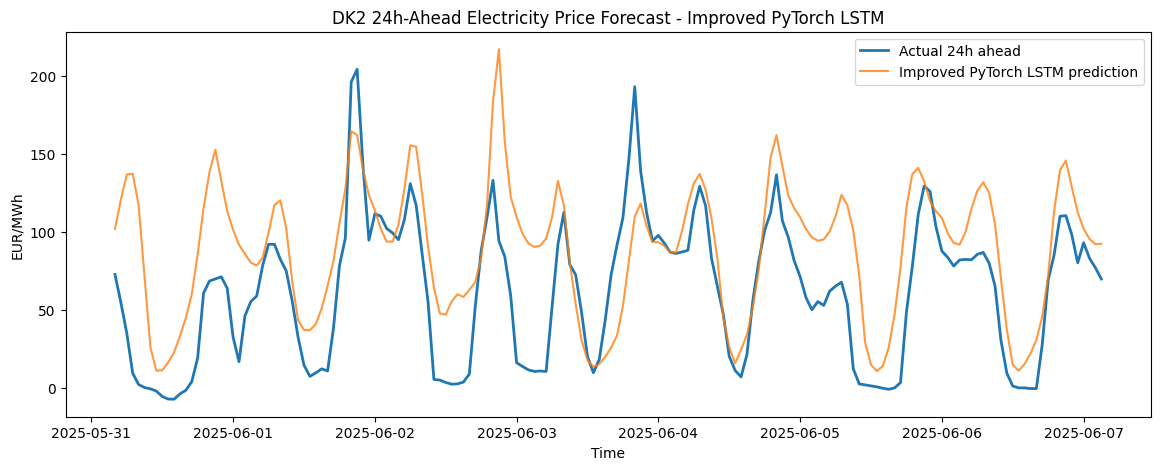

In [44]:
time_test_seq = time_test.iloc[window_size:].reset_index(drop=True)

sample_size = 168

plt.figure(figsize=(14, 5))

plt.plot(
    time_test_seq.iloc[:sample_size],
    y_true[:sample_size],
    label="Actual 24h ahead",
    linewidth=2
)

plt.plot(
    time_test_seq.iloc[:sample_size],
    y_pred[:sample_size],
    label="Improved PyTorch LSTM prediction",
    alpha=0.8
)

plt.title("DK2 24h-Ahead Electricity Price Forecast - Improved PyTorch LSTM")
plt.xlabel("Time")
plt.ylabel("EUR/MWh")
plt.legend()
plt.show()

## Conclusion

This notebook implements an improved PyTorch LSTM model for 24-hour-ahead DK2 electricity price forecasting.

The model uses sequences of the previous 24 hours of features to predict the electricity price 24 hours ahead. The architecture includes a two-layer LSTM, dropout, layer normalization, AdamW optimization, gradient clipping, a learning-rate scheduler and temporal validation with early stopping.

The Improved PyTorch LSTM achieved a MAE of 34.43 EUR/MWh and RMSE of 46.71 EUR/MWh. It did not outperform the XGBoost model or the current-price baseline. This suggests that, for this dataset and forecasting setup, gradient-boosted trees handle the tabular energy-market features better than the LSTM sequence model.

The result is still valuable because it provides a deep-learning benchmark and confirms that model complexity alone does not guarantee better forecasting performance.